<div align="center">

# SpecAugment Audio Augmentation Pipeline
## Time–Frequency Masking with Faithful Waveform (.wav) Reconstruction

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![librosa](https://img.shields.io/badge/librosa-STFT%2FISTFT-9cf?style=flat-square)
![SpecAugment](https://img.shields.io/badge/SpecAugment-time%2Ffreq%20masking-orange?style=flat-square)
![Output](https://img.shields.io/badge/output-.wav-success?style=flat-square)

</div>

For every source recording we emit **N masked variants as `.wav`** :

- masking is applied to the **linear STFT**, then inverted with **ISTFT using the original phase**
- → reconstruction is *exact* outside the masked regions — **no Griffin-Lim, no phase estimation**

| Section | Content |
|---|---|
| 1 | Source data — FOCH pathologies (+ optional SVD healthy control), patient-level metadata |
| 2 | SpecAugment core — STFT time/frequency masking → ISTFT (`.wav`) |
| 3 | Smoke test — round-trip fidelity + one augmented example (spectrogram + audio) |
| 4 | Batch generation — per-class budget → `specaugment/*.wav` + manifest |
| 5 | Quality checks — original vs augmented spectrograms, playback |


---

## Overview

This notebook is the **SpecAugment arm** of the augmentation comparison (SpecAugment vs Mixup vs
SMOTE) feeding `Classification_Algo/4_0_foch_test.ipynb`. It is the waveform-domain counterpart to
`mel_vae_augmentation.ipynb`: where the Mel-VAE *generates* new spectrograms, SpecAugment *masks*
existing recordings — a cheap, label-preserving regulariser that needs no training.

### "Can the augmented audio really be a `.wav` (not `.npy`)?" — yes.

Classic SpecAugment masks a **mel** spectrogram, and mel spectrograms are not cleanly invertible to
audio (you would need Griffin-Lim, which estimates the discarded phase and adds artifacts). We avoid
that entirely by masking the **linear STFT** instead:

```
y ──▶ STFT ──▶ complex D = magnitude · e^{j·phase}
                     │  zero whole rows (frequency bands) and columns (time spans) of D
                     ▼
              masked D' ──▶ ISTFT (original phase preserved) ──▶ y'  ──▶  .wav
```

Zeroing complex STFT bins is exactly "mask the magnitude, keep the phase". So `istft` reconstructs
the signal **perfectly outside the masked regions** and the masked bands become near-silent. The
result is a genuine `.wav` whose re-computed spectrogram carries the time/frequency masks — which is
precisely what `4_0` needs, since its `Dataset` recomputes a Mel spectrogram from the waveform.

> **Run order:** execute top-to-bottom. Section 4 writes the `.wav` files and the manifest; Sections
> 3 and 5 are visual/audio sanity checks and can be re-run freely.

---

### Cell 0 — Imports


In [1]:
# ── Core scientific stack ────────────────────────────────────────────────────────
import os, glob, random, warnings
import numpy as np
import pandas as pd

# ── Audio I/O & feature extraction ───────────────────────────────────────────────
import librosa
import librosa.display
import soundfile as sf

# ── Plotting & playback ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import IPython.display as ipd

warnings.filterwarnings('ignore')

# Reproducibility: a master RNG is used so every run produces the same masks.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('Imports loaded.')


Imports loaded.


### Cell — Configuration

One place for every knob: filesystem paths, the audio/STFT front-end (kept identical to
`4_0_foch_test.ipynb` so the masks land on the same time–frequency grid the classifier sees), the
SpecAugment mask parameters, and the class scheme.

**Paths are absolute on purpose** — the manifest is written with absolute `filepath`s so it can be
consumed directly by `4_0` (which runs from `Classification_Algo/`, a different working directory).

**Mask parameters.** `FREQ_MASK_PARAM` is the maximum width of a frequency band in STFT *bins*
(bin width = `SR/N_FFT` = 15.6 Hz, so 80 bins ≈ 1.25 kHz). `TIME_MASK_PARAM` is the maximum width of
a time span in STFT *frames* (frame hop = `HOP_LENGTH/SR` = 16 ms, so 40 frames ≈ 0.64 s).
`TIME_MASK_P` caps a single time mask at a fraction of the clip so short recordings are never wiped.


In [2]:
# ── Project paths (absolute → manifest is consumable by 4_0_foch_test.ipynb) ──────
PROJECT_ROOT    = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY'
CSV_PATH        = os.path.join(PROJECT_ROOT, 'csv_best', 'orl_df_vowel_master.csv')
FOCH_AUDIO_DIR  = os.path.join(PROJECT_ROOT, 'Segmented_Voyelles_Best')      # FOCH pathological vowels
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'                  # Saarbruecken control group

AUG_DIR        = os.path.join(PROJECT_ROOT, 'Segmented_Voyelles_Augmented')
OUTPUT_WAV_DIR = os.path.join(AUG_DIR, 'specaugment')                        # ← augmented .wav land here
MANIFEST_PATH  = os.path.join(PROJECT_ROOT, 'data_augmentation', 'augmentation_manifest_specaug.csv')
os.makedirs(OUTPUT_WAV_DIR, exist_ok=True)

# ── Audio / STFT front-end (matches 4_0_foch_test.ipynb) ─────────────────────────
TARGET_SR  = 16_000
MAX_LEN_S  = 4.0
MAX_LEN    = int(TARGET_SR * MAX_LEN_S)   # 64 000 samples (truncate only; no padding on output)
N_FFT      = 1024
HOP_LENGTH = 256
N_BINS     = N_FFT // 2 + 1               # 513 linear-frequency bins (0–8 kHz)

# ── SpecAugment hyperparameters ──────────────────────────────────────────────────
N_FREQ_MASKS    = 2
FREQ_MASK_PARAM = 80      # max frequency-band width, in STFT bins  (~1.25 kHz)
N_TIME_MASKS    = 2
TIME_MASK_PARAM = 40      # max time-span width, in STFT frames     (~0.64 s)
TIME_MASK_P     = 0.2     # a single time mask never exceeds this fraction of the clip

# ── Classes (mirror 4_0: three FOCH pathologies + SVD healthy control) ───────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
INCLUDE_HEALTHY    = True
N_HEALTHY          = 100  # subsample of SVD /a/ habitual-pitch controls

print('Configuration loaded.')
print(f'  Output WAV dir : {OUTPUT_WAV_DIR}')
print(f'  Manifest       : {MANIFEST_PATH}')
print(f'  STFT           : n_fft={N_FFT}, hop={HOP_LENGTH} → {N_BINS} bins')
print(f'  Masks          : {N_FREQ_MASKS}x freq (<={FREQ_MASK_PARAM} bins) + '
      f'{N_TIME_MASKS}x time (<={TIME_MASK_PARAM} frames)')


Configuration loaded.
  Output WAV dir : C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY\Segmented_Voyelles_Augmented\specaugment
  Manifest       : C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY\data_augmentation\augmentation_manifest_specaug.csv
  STFT           : n_fft=1024, hop=256 → 513 bins
  Masks          : 2x freq (<=80 bins) + 2x time (<=40 frames)


---

## Section 1 — Source Data Preparation

Build the pool of *real* recordings to augment, mirroring the selection logic of
`4_0_foch_test.ipynb` so SpecAugment operates on exactly the population the classifier trains on.

1. **Load & clean labels** — read `orl_df_vowel_master.csv`, strip whitespace/case noise from `VSL`.
2. **Filter to the three target pathologies** and reassign canonical class names.
3. **Patient-level dedup** on `Last_Name` (one recording per patient) — same as `4_0`.
4. **Resolve audio paths** in `Segmented_Voyelles_Best` and keep only files present on disk.
5. **Healthy control (optional)** — Saarbruecken `*a_h.wav` (/a/ habitual pitch), subsampled to
   `N_HEALTHY`. Skipped gracefully if the SVD directory is unavailable.

> **No-leakage note.** Every augmented variant generated later inherits the `Last_Name` of the
> recording it was derived from. `4_0` excludes, per fold, any augmented row whose `Last_Name`
> appears in that fold's validation set — so carrying the correct `Last_Name` here is what keeps the
> comparison honest.


In [3]:
# ── 1–4. FOCH pathological recordings ─────────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}      # {'pr': 'PR', ...}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)

# One recording per patient (Last_Name) — prevents near-duplicate over-augmentation.
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')

df_patho['filepath'] = df_patho['File_Name'].apply(lambda f: os.path.join(FOCH_AUDIO_DIR, f))
df_patho = df_patho[df_patho['filepath'].apply(os.path.isfile)]
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 5. Healthy control group (Saarbruecken /a/ habitual pitch) ───────────────────
frames = [df_patho]
if INCLUDE_HEALTHY and os.path.isdir(SVD_HEALTHY_DIR):
    svd = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
    random.seed(SEED)
    svd = random.sample(svd, min(N_HEALTHY, len(svd)))
    df_healthy = pd.DataFrame({
        'filepath':  svd,
        'File_Name': [os.path.basename(f) for f in svd],
        # SVD patient id = folder name <patient_id>/vowels/<file>
        'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd],
        'label_str': HEALTHY_LABEL,
    })
    frames.append(df_healthy)
elif INCLUDE_HEALTHY:
    print(f'WARNING: SVD healthy dir not found ({SVD_HEALTHY_DIR}) — augmenting pathologies only.')

df_src = pd.concat(frames, ignore_index=True)

print('Source recordings per class:')
print(df_src['label_str'].value_counts().to_string())
print(f'\nTotal source recordings: {len(df_src)}')


Source recordings per class:
label_str
Healthy            100
PR                  72
LMB                 67
fuite glottique     26

Total source recordings: 265


---

## Section 2 — SpecAugment Core (STFT masking → waveform)

Three small, in-place helpers and one public function:

- `load_waveform` — mono, 16 kHz, truncated to `MAX_LEN` (no zero-padding, so saved clips stay
  natural-length).
- `_freq_mask` / `_time_mask` — zero up to *n* horizontal (frequency) / vertical (time) bands of the
  **complex** STFT.
- `spec_augment_waveform` — STFT → mask → ISTFT with the original phase, returning a `float32`
  waveform ready for `soundfile.write`.

> Time warping (the third SpecAugment operation) is deliberately omitted: it gives the smallest
> benefit in the original paper and complicates faithful waveform inversion. Note also that
> overlap-add in `istft` *attenuates* rather than hard-zeroes a masked time span — this avoids
> audible clicks and is the intended behaviour.


In [4]:
def load_waveform(path, sr=TARGET_SR, max_len=MAX_LEN):
    """Load mono audio at `sr`; truncate to `max_len` (no padding → natural-length .wav out)."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    if len(y) > max_len:
        y = y[:max_len]
    return y.astype(np.float32)


def _freq_mask(D, n_masks, F, rng):
    """Zero up to `n_masks` horizontal (frequency) bands of the complex STFT, in place."""
    n_bins = D.shape[0]
    for _ in range(n_masks):
        f = int(rng.integers(0, F + 1))
        if f == 0 or f >= n_bins:
            continue
        f0 = int(rng.integers(0, n_bins - f))
        D[f0:f0 + f, :] = 0.0
    return D


def _time_mask(D, n_masks, T, p, rng):
    """Zero up to `n_masks` vertical (time) bands of the complex STFT, in place."""
    n_frames = D.shape[1]
    t_upper  = min(T, int(p * n_frames))      # cap a mask at a fraction of the clip
    if t_upper < 1:
        return D
    for _ in range(n_masks):
        t = int(rng.integers(0, t_upper + 1))
        if t == 0 or t >= n_frames:
            continue
        t0 = int(rng.integers(0, n_frames - t))
        D[:, t0:t0 + t] = 0.0
    return D


def spec_augment_waveform(y, rng,
                          n_freq=N_FREQ_MASKS, F=FREQ_MASK_PARAM,
                          n_time=N_TIME_MASKS, T=TIME_MASK_PARAM, p=TIME_MASK_P):
    """SpecAugment on the linear STFT, inverted to a waveform with the ORIGINAL phase.

    Zeroing complex STFT bins == masking the magnitude while leaving the phase untouched, so
    `istft` reconstructs the signal exactly outside the masked regions (no Griffin-Lim, no phase
    estimation). The returned float32 waveform is a genuine .wav whose re-computed spectrogram
    carries the time/frequency masks.
    """
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)   # complex (N_BINS, frames)
    D = _freq_mask(D, n_freq, F, rng)
    D = _time_mask(D, n_time, T, p, rng)
    y_aug = librosa.istft(D, hop_length=HOP_LENGTH, length=len(y))
    return y_aug.astype(np.float32)


---

## Section 3 — Smoke Test

Two quick checks before generating thousands of files:

1. **Round-trip fidelity** — with *no* masks, `istft(stft(y))` must reproduce `y` to numerical
   precision. A near-zero relative RMSE confirms the lossless `.wav` path (the whole premise of this
   notebook).
2. **One worked example** — apply SpecAugment to a single recording and compare spectrograms (the
   masked bands should be clearly visible) and audio side by side.


Round-trip relative RMSE (no mask): 8.11e-08  -> ~0 confirms lossless STFT/ISTFT


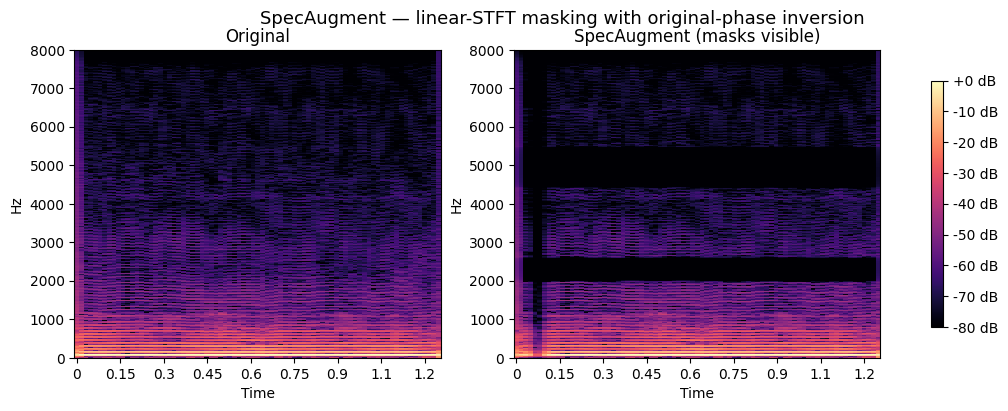

Playback (original -> SpecAugment):


In [9]:
# 1) Round-trip fidelity: with NO masks, istft(stft(y)) must match y -> validates the .wav path.
y0    = load_waveform(df_src.iloc[0]['filepath'])
D0    = librosa.stft(y0, n_fft=N_FFT, hop_length=HOP_LENGTH)
y0_rt = librosa.istft(D0, hop_length=HOP_LENGTH, length=len(y0))
rt_err = np.sqrt(np.mean((y0 - y0_rt) ** 2)) / (np.std(y0) + 1e-9)
print(f'Round-trip relative RMSE (no mask): {rt_err:.2e}  -> ~0 confirms lossless STFT/ISTFT')

# 2) One augmented example -> spectrogram before/after + audio playback.
y_aug = spec_augment_waveform(y0, np.random.default_rng(0))


def _logmag(y):
    """Log-magnitude (dB) linear spectrogram for display."""
    return librosa.amplitude_to_db(
        np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)), ref=np.max)


fig, ax = plt.subplots(1, 2, figsize=(13, 4))
img = None
for a, (yy, title) in zip(ax, [(y0, 'Original'), (y_aug, 'SpecAugment (masks visible)')]):
    img = librosa.display.specshow(_logmag(yy), sr=TARGET_SR, hop_length=HOP_LENGTH,
                                   x_axis='time', y_axis='hz', ax=a)
    a.set_title(title)
    a.set_ylim(0, 8000)
fig.colorbar(img, ax=ax, format='%+2.0f dB', shrink=0.8)
plt.suptitle('SpecAugment — linear-STFT masking with original-phase inversion', fontsize=13)
plt.show()

print('Playback (original -> SpecAugment):')
ipd.display(ipd.Audio(y0,    rate=TARGET_SR))
ipd.display(ipd.Audio(y_aug, rate=TARGET_SR))


---

## Section 4 — Batch Generation

For each class, generate `N_AUG_PER_CLASS` masked variants by cycling over that class's source files
with fresh random masks each time, writing one `.wav` per variant into `specaugment/`. Minority
pathologies are oversampled more aggressively to rebalance the training pool.

**Manifest** (`augmentation_manifest_specaug.csv`) — one row per file, with exactly the columns
`4_0_foch_test.ipynb` (Cellule 5) expects:

| Column | Meaning |
|---|---|
| `filepath` | absolute path to the `.wav` |
| `File_Name` | basename |
| `Last_Name` | **source patient** (real or augmented) — drives `4_0`'s per-fold leakage exclusion |
| `label_str` | `PR` / `LMB` / `fuite glottique` / `Healthy` |
| `is_aug` | `True` for SpecAugment variants, `False` for the real reference rows |
| `source_filepath` | provenance of each augmented clip (empty for real rows) |

Real rows (`is_aug=False`) are included so the manifest can stand alone / be audited; `4_0` keeps
only the `is_aug=True` rows.


In [7]:
# Augmentation budget — number of masked .wav variants to generate per class.
# Oversample minority pathologies more aggressively to rebalance the train pool.
N_AUG_PER_CLASS = {
    'PR':              60,
    'LMB':             90,
    'fuite glottique': 120,
    'Healthy':         60,
}


def generate_specaugment(df_src, n_per_class=N_AUG_PER_CLASS, seed=SEED):
    master = np.random.default_rng(seed)   # one stream -> reproducible masks across the whole run
    rows = []

    # Real reference rows (is_aug=False) — lets the manifest stand alone / be audited.
    for _, r in df_src.iterrows():
        rows.append({'filepath': r['filepath'], 'File_Name': r['File_Name'],
                     'Last_Name': r['Last_Name'], 'label_str': r['label_str'],
                     'is_aug': False, 'source_filepath': ''})

    # Synthetic rows (is_aug=True) — cycle the class's source files with fresh masks.
    for cls, n in n_per_class.items():
        pool = df_src[df_src['label_str'] == cls].reset_index(drop=True)
        if len(pool) == 0 or n <= 0:
            print(f'[SKIP] {cls}: {"no source files" if len(pool) == 0 else "budget 0"}')
            continue
        print(f'Generating {n:3d} SpecAugment variants for {cls:<16} (from {len(pool)} sources)...')
        for i in range(n):
            src   = pool.iloc[i % len(pool)]
            y_aug = spec_augment_waveform(load_waveform(src['filepath']), master)
            stem  = os.path.splitext(src['File_Name'])[0]
            fname = f'SPECAUG_{cls.upper().replace(" ", "_")}_{i:04d}_{stem}.wav'
            out   = os.path.join(OUTPUT_WAV_DIR, fname)
            sf.write(out, y_aug, TARGET_SR)
            rows.append({'filepath': out, 'File_Name': fname,
                         'Last_Name': src['Last_Name'],          # <- inherit source patient (no leakage)
                         'label_str': cls, 'is_aug': True,
                         'source_filepath': src['filepath']})

    manifest = pd.DataFrame(rows)
    manifest.to_csv(MANIFEST_PATH, index=False)
    print(f'\nManifest saved: {MANIFEST_PATH}')
    summary = manifest.groupby(['label_str', 'is_aug']).size().unstack(fill_value=0)
    print(summary.to_string())
    return manifest


manifest_df = generate_specaugment(df_src)


Generating  60 SpecAugment variants for PR               (from 72 sources)...
Generating  90 SpecAugment variants for LMB              (from 67 sources)...
Generating 120 SpecAugment variants for fuite glottique  (from 26 sources)...
Generating  60 SpecAugment variants for Healthy          (from 100 sources)...

Manifest saved: C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY\data_augmentation\augmentation_manifest_specaug.csv
is_aug           False  True 
label_str                    
Healthy            100     60
LMB                 67     90
PR                  72     60
fuite glottique     26    120


---

## Section 5 — Quality Checks

A final look that the variants are useful augmentation rather than noise:

- **Real vs SpecAugment spectrograms** per class — the augmented panel should look like the real one
  with a few blanked time/frequency stripes (not a different signal).
- **Playback** — one augmented clip per class should still sound like a (slightly notched) sustained
  vowel.


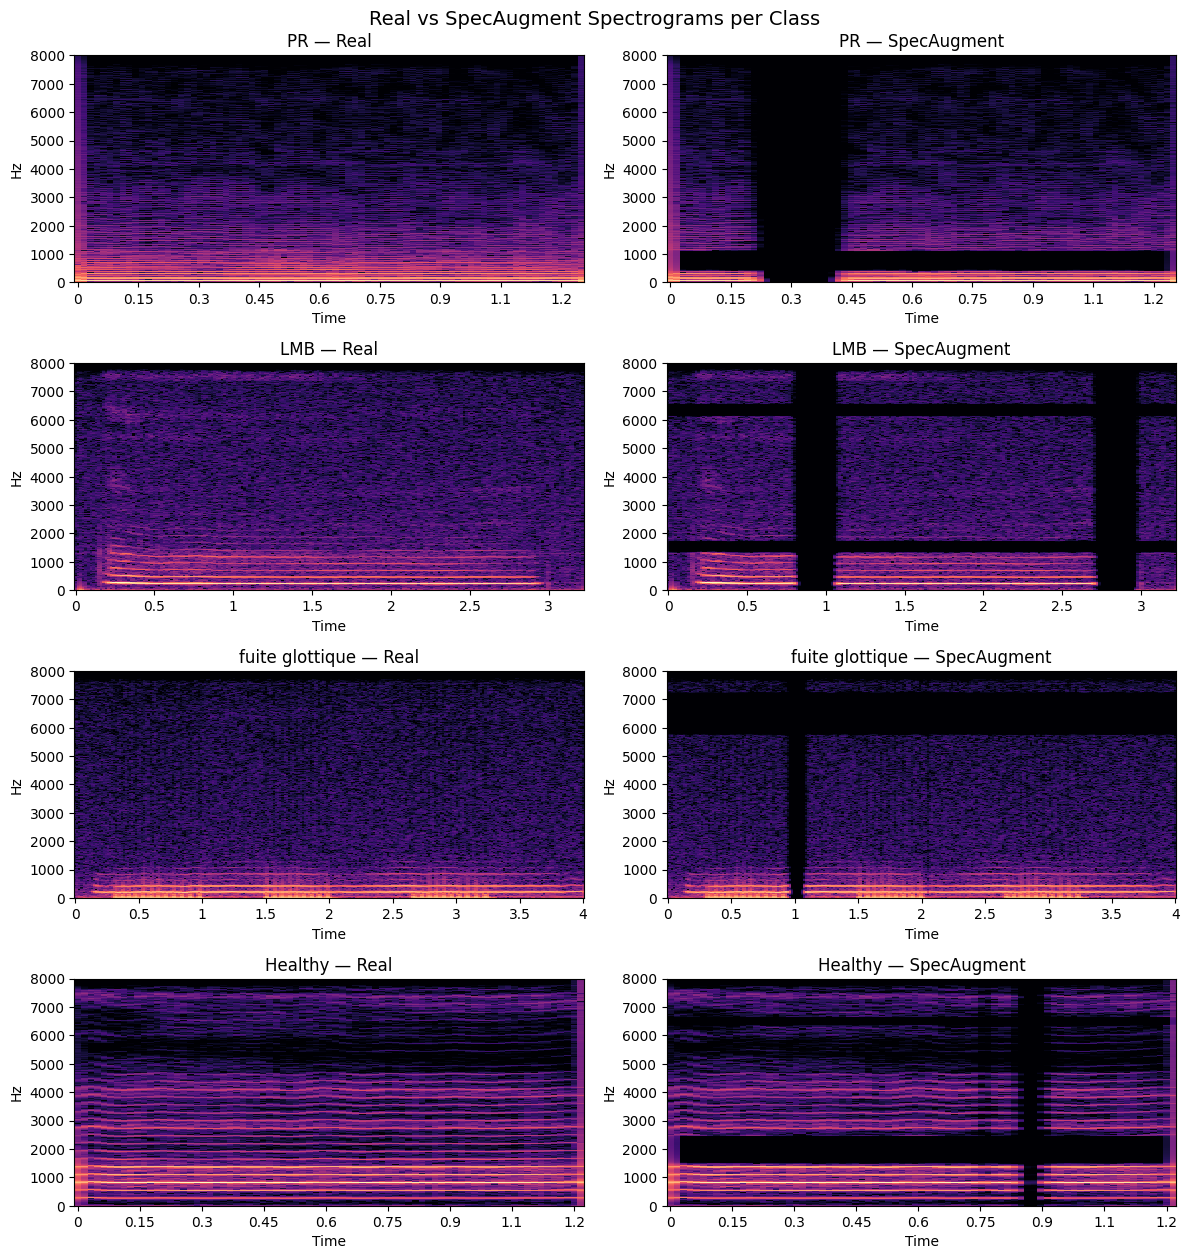

=== SpecAugment Audio Playback ===
[PR]


[LMB]


[fuite glottique]


[Healthy]


In [8]:
# Real vs augmented spectrogram for one source per class
classes = [c for c in N_AUG_PER_CLASS if (df_src['label_str'] == c).any()]
fig, axes = plt.subplots(len(classes), 2, figsize=(12, 3.2 * len(classes)))
if len(classes) == 1:
    axes = axes.reshape(1, 2)

viz_rng = np.random.default_rng(123)
for row, cls in enumerate(classes):
    src = df_src[df_src['label_str'] == cls].iloc[0]
    y   = load_waveform(src['filepath'])
    y_a = spec_augment_waveform(y, viz_rng)
    for col, (yy, tag) in enumerate([(y, 'Real'), (y_a, 'SpecAugment')]):
        librosa.display.specshow(_logmag(yy), sr=TARGET_SR, hop_length=HOP_LENGTH,
                                 x_axis='time', y_axis='hz', ax=axes[row, col])
        axes[row, col].set_ylim(0, 8000)
        axes[row, col].set_title(f'{cls} — {tag}')

plt.suptitle('Real vs SpecAugment Spectrograms per Class', fontsize=14)
plt.tight_layout()
plt.show()

# Playback — one augmented sample per class
print('=== SpecAugment Audio Playback ===')
for cls in classes:
    src = df_src[df_src['label_str'] == cls].iloc[0]
    y_a = spec_augment_waveform(load_waveform(src['filepath']), viz_rng)
    print(f'[{cls}]')
    ipd.display(ipd.Audio(y_a, rate=TARGET_SR))


---

## Conclusion & Outputs

This notebook applies **SpecAugment** (time + frequency masking) to the FOCH training population and
materialises the result as **`.wav`** files, using linear-STFT masking with original-phase ISTFT so
the audio is faithful outside the masked bands.

**Artifacts written**

| Path | Contents |
|---|---|
| `../Segmented_Voyelles_Augmented/specaugment/*.wav` | SpecAugment variants — **WavLM + Mel branches** |
| `augmentation_manifest_specaug.csv` | Per-file manifest (real + augmented), `4_0`-compatible |

**How to consume in `4_0_foch_test.ipynb`** — add the manifest to the pool in Cellule 1:

```python
AUG_MANIFESTS = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
    r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/data_augmentation/augmentation_manifest_specaug.csv',
]
```

For a clean **head-to-head comparison**, point `AUG_MANIFESTS` at *only* the SpecAugment manifest
(and run a no-augmentation baseline with an empty list) so the K-fold OOF metrics isolate the effect
of each strategy.

**Caveats**

- We mask **linear-frequency** bins (band-stop in Hz), not classic mel channels — functionally
  equivalent for regularisation, and `4_0` recomputes its Mel from the waveform so the masks
  propagate either way.
- SpecAugment is canonically applied **online** (fresh masks every epoch). Materialising to `.wav`
  *fixes* the masks per file — the price of feeding the existing wav-based `4_0` pipeline. For pure
  online SpecAugment you would instead mask the Mel tensor inside `FochVowelDataset`.
- Each augmented row inherits its **source patient's `Last_Name`**, so `4_0`'s per-fold exclusion
  keeps validation folds free of augmented leakage.
- Masking is destructive, not generative: SpecAugment diversifies existing classes but cannot invent
  variation for classes with very few patients — pair it with the Mel-VAE for the rarest pathologies.
